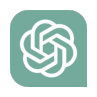

In [1]:
# exercitiul 2

from PIL import Image, ImageFilter
from pathlib import Path
import matplotlib.pyplot as plt
import math


# 1) vizualizare imagine

def show_image(image_path):
    image = Image.open(image_path)
    plt.figure(figsize=(1, 1))
    plt.imshow(image)
    plt.axis("off")
    plt.show()


show_image("images/chatGPT.png")


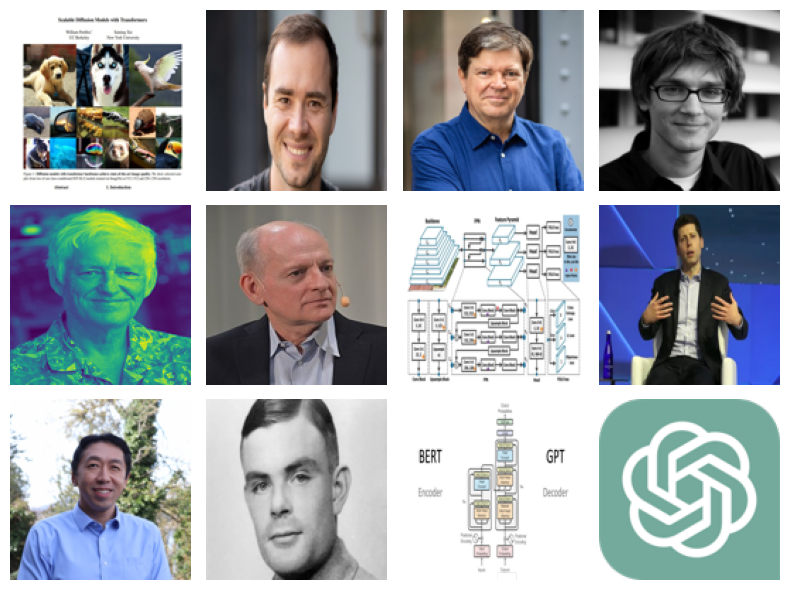

In [2]:
# 2) redimensionare imagini + vizualizare

dimensions = (128, 128)


def load_images(path):
    exts = [".jpg", ".webp", ".png"]
    imgs = []
    for ext in exts:
        imgs.extend(Path(path).glob(f"*{ext}"))
    return imgs


def resize_image_128(image_path):
    image = Image.open(image_path)
    image_resized = image.resize(dimensions)
    return image_resized


def show_images(imgs, grayscale=False):
    num_imgs = len(imgs)
    cols = 4
    rows = math.ceil(num_imgs / cols)
    plt.figure(figsize=(cols * 2, rows * 2))
    for i, img in enumerate(imgs):
        plt.subplot(rows, cols, i + 1)
        if grayscale:
            plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(img)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


images = load_images("images")
resized_images = [resize_image_128(image) for image in images]
show_images(resized_images)

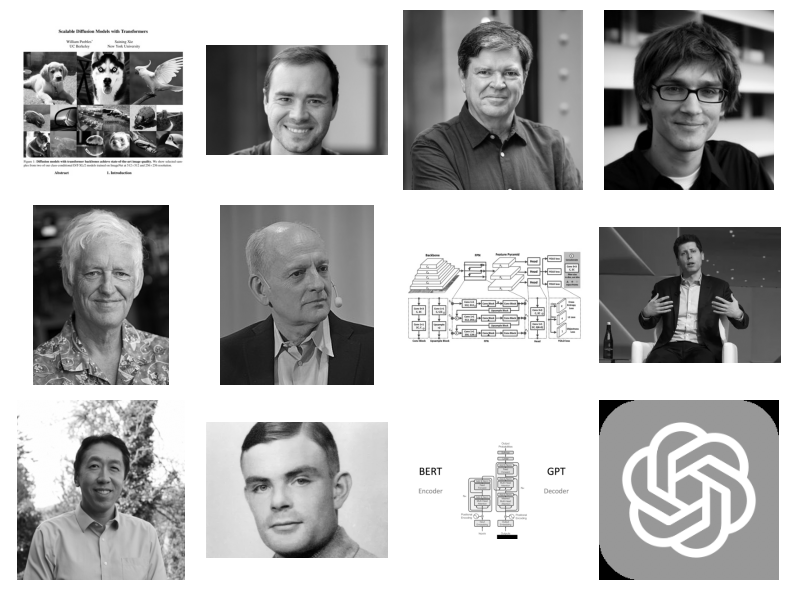

In [3]:
# 3) img to grayscale

def convert_to_grayscale(image_path):
    image = Image.open(image_path)
    grayscale_image = image.convert("L")
    return grayscale_image


grayscale_images = [convert_to_grayscale(img) for img in images]
show_images(grayscale_images, grayscale=True)

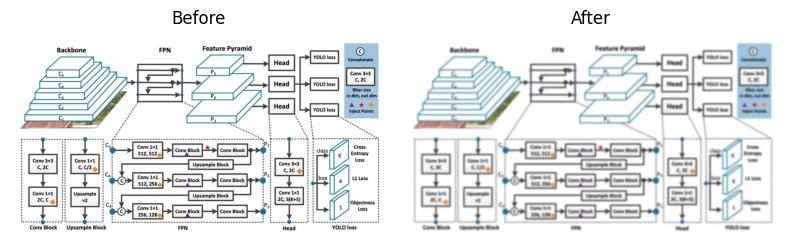

In [4]:
# 4) gaussian blur

def blur_image(image_path, radius=2):
    img = Image.open(image_path)
    blurred_img = img.filter(ImageFilter.GaussianBlur(radius=radius))
    return blurred_img


def before_and_after(image1, image2):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image1)
    plt.title("Before")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(image2)
    plt.title("After")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


image = images[6]
blurred_image = blur_image(image)
before_and_after(Image.open(image), blurred_image)

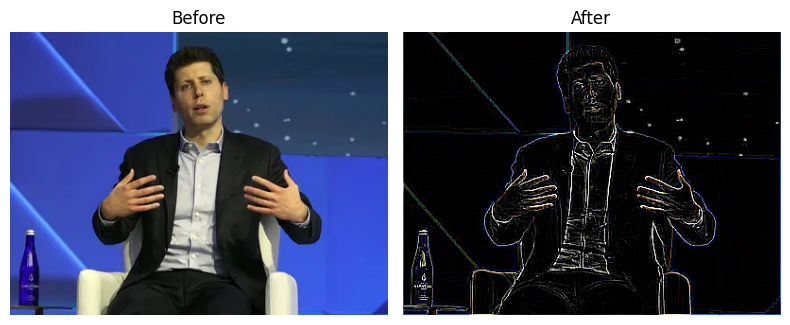

In [5]:
# 5) Muchii before and after

def find_edge(image_path):
    image = Image.open(image_path)
    image_edges = image.filter(ImageFilter.FIND_EDGES)
    return image_edges


image = images[7]
edges = find_edge(image)
before_and_after(Image.open(image), edges)

In [6]:
# exercitiul 3

from nltk import sent_tokenize, word_tokenize

text_path = "texts.txt"
text = open(text_path, "r", encoding="utf-8").read()

# 1) number of sentences

sentences = sent_tokenize(text)
print(len(sentences))

10


In [7]:
# 2) number of words

tokenized_words = word_tokenize(text)
words = [w for w in tokenized_words if w.isalpha() and not w.isdigit()]
print(len(words))

158


In [8]:
# 3) number of distinct words

distinct_words = set(words)
print(len(distinct_words))

95


In [9]:
# 4) shortest and longest word

shortest = min(distinct_words, key=len)
longest = max(distinct_words, key=len)

print(shortest, longest)

o Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm


In [10]:
# 5) text without diacritice

import unicodedata

fixed_text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
print(fixed_text)

Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam sa fiti activi si sa adresati intrebari atunci cand 
ceva nu este clar. Fie ca este vorba de o discutie in timp real 
sau prin intermediul platformei Teams, canalul ”general”, suntem 
aici sa va sprijinim.
Succes si sa inceapa ave

In [11]:
# 6) synonyms of longest word

from nltk.corpus import wordnet as wn

synonyms=set()
for syn in wn.synsets(longest):
    for lemma in syn.lemmas():
        synonyms.add(lemma.name())

print(synonyms)

set()


In [12]:
# exercitiul 4

import pandas as pd

# normalizare exercitiu 1

df = pd.read_csv("https://raw.githubusercontent.com/lauradiosan/AI-UBB/refs/heads/main/2025-2026/labs/lab02/data/surveyDataSience.csv", low_memory=False)

In [13]:
# durata anilor de studii universitare  ( scalare min max pt range 0 1)
edu_map={
    "Bachelor's degree":3,
     "Master’s degree": 5,
    "Doctoral degree": 8,
    "Some college/university study without earning a bachelor’s degree": 1.5,
    "Professional degree": 8,
    "I prefer not to answer": None,
    "No formal education past high school": 0,
}

df["higher_ed_time"]=df["Q4"].map(edu_map)
mean_ed_time=df["higher_ed_time"].mean()
df["higher_ed_time"]=df["higher_ed_time"].fillna(mean_ed_time)

studies_duration=df["higher_ed_time"].values
duration_scaled=[(d-min(studies_duration)/(max(studies_duration)-min(studies_duration))) for d in studies_duration]

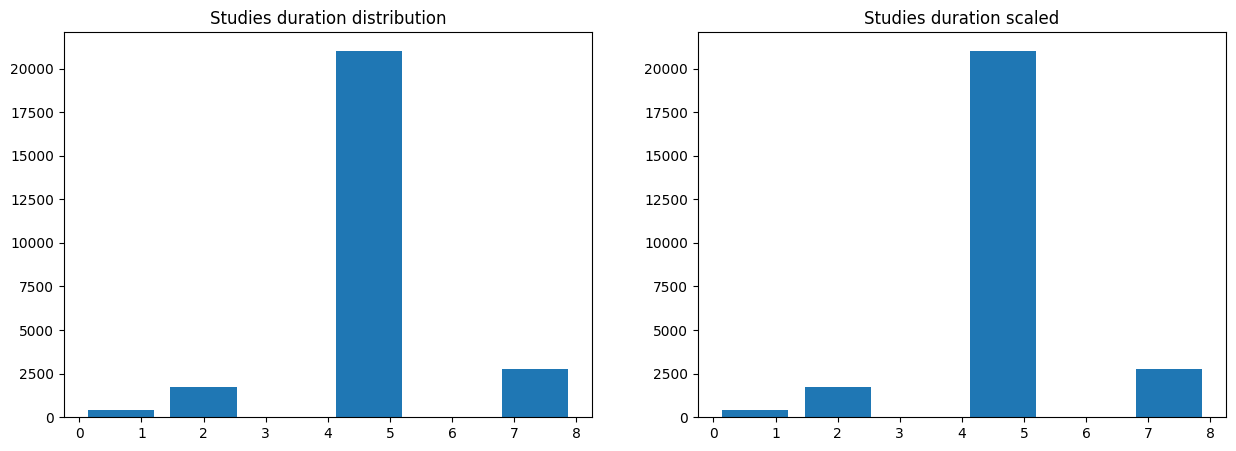

In [14]:
# plot studies
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,5))
ax1.hist(studies_duration, 6, rwidth=0.8)
ax1.set_title("Studies duration distribution")
ax2.hist(duration_scaled,6,rwidth=0.8)
ax2.set_title("Studies duration scaled")
plt.show()


In [15]:
# vechimea in programare (scalare log outlier 25)
exp_map = {
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25,
}

df["prog_exp"]=df["Q6"].map(exp_map)
df["prog_exp"]=df["prog_exp"].fillna(df["prog_exp"].mean())

exp_years=df["prog_exp"].values
exp_scaled=[math.log(x+1) for x in exp_years]

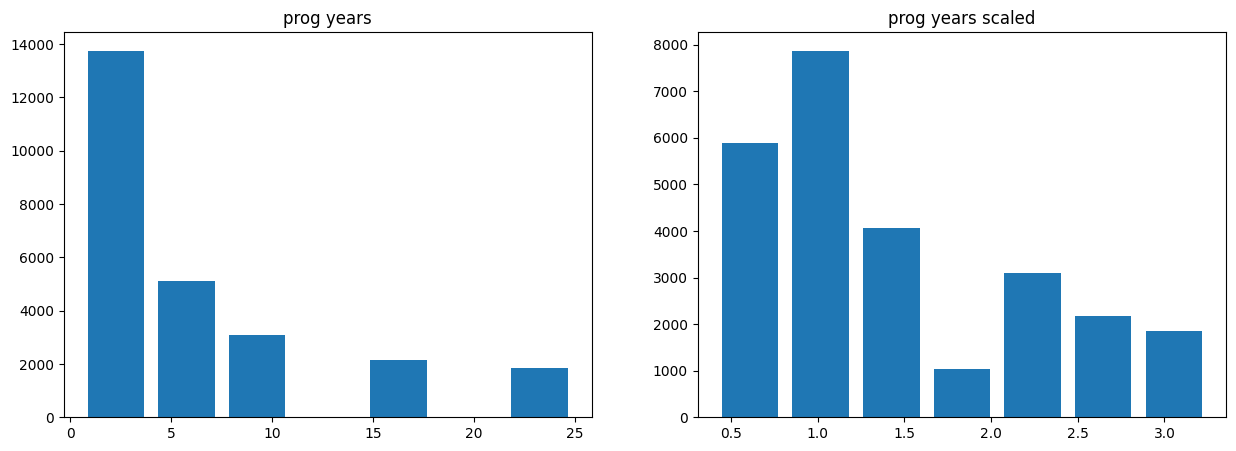

In [16]:
# plot vechime programare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
ax1.hist(exp_years, 7,rwidth=0.8)
ax1.set_title('prog years')
ax2.hist(exp_scaled, 7,rwidth=0.8)
ax2.set_title('prog years scaled')
plt.show()

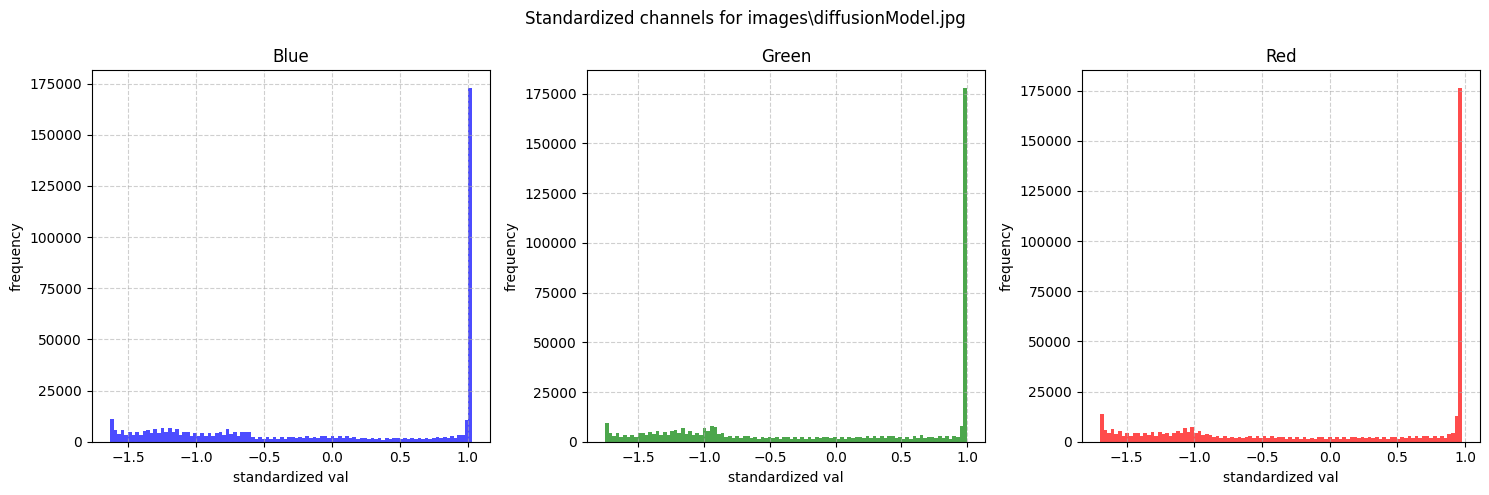

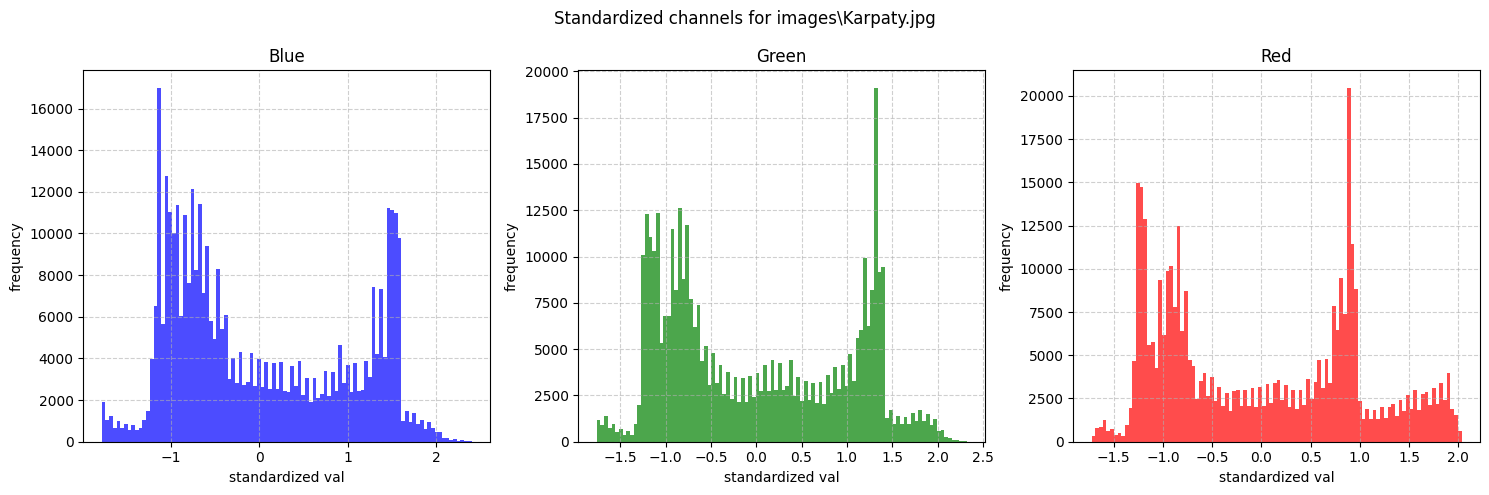

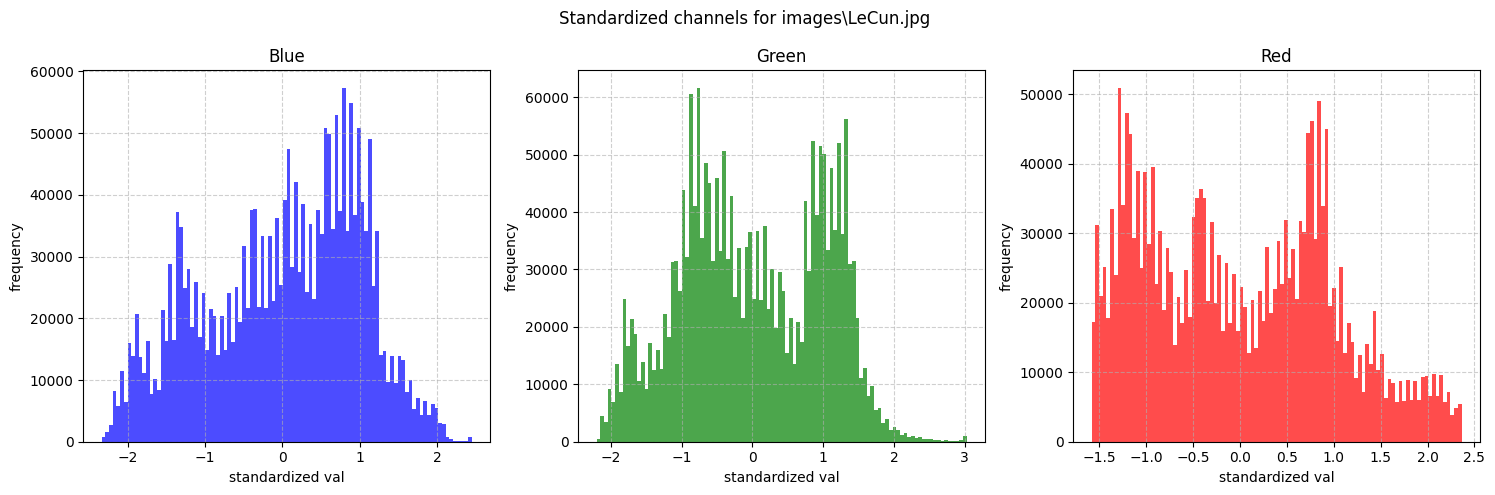

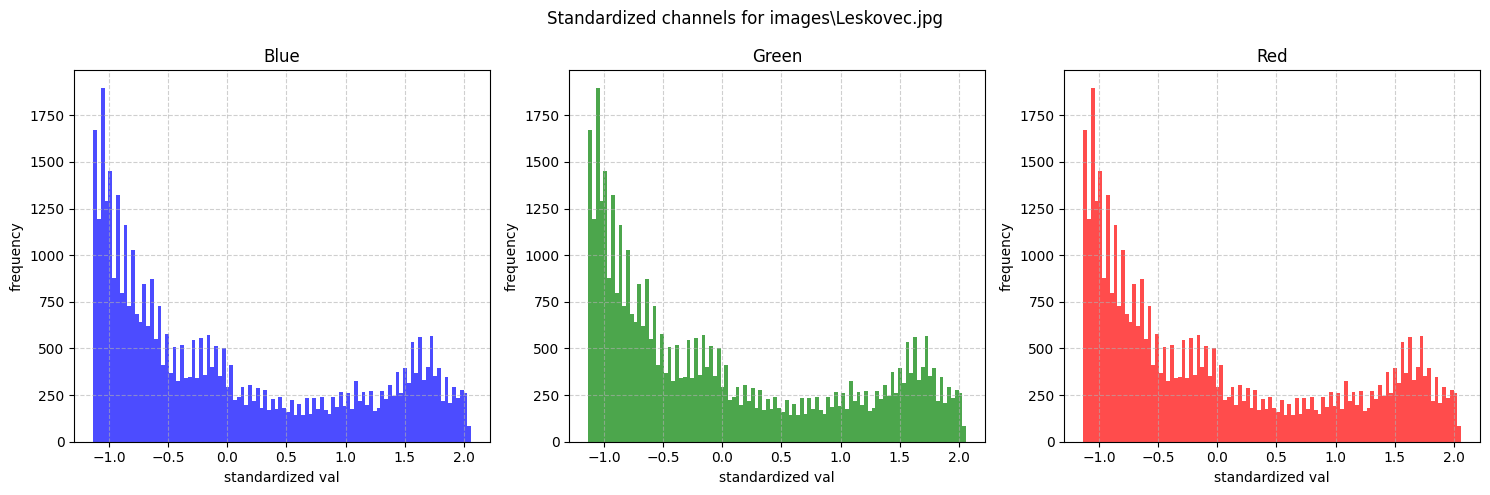

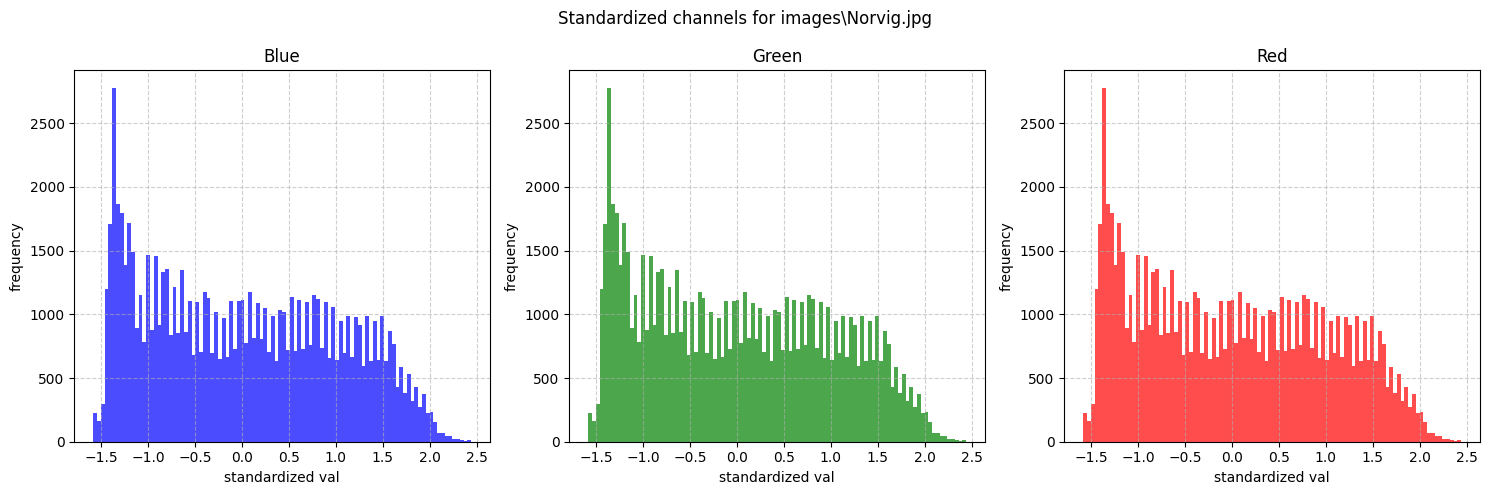

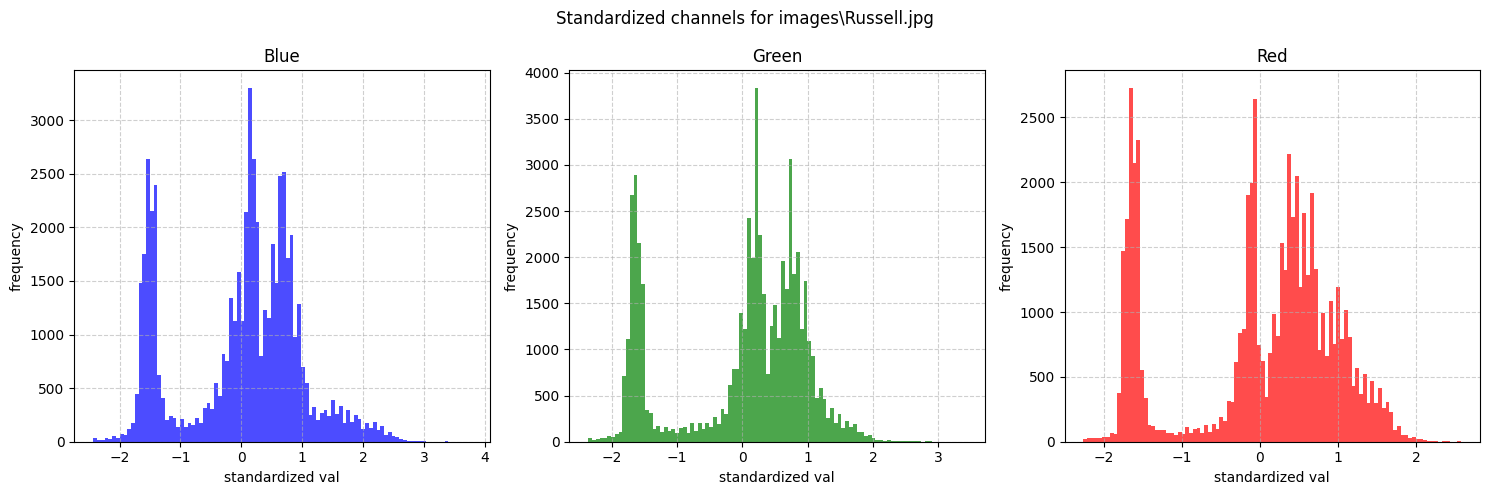

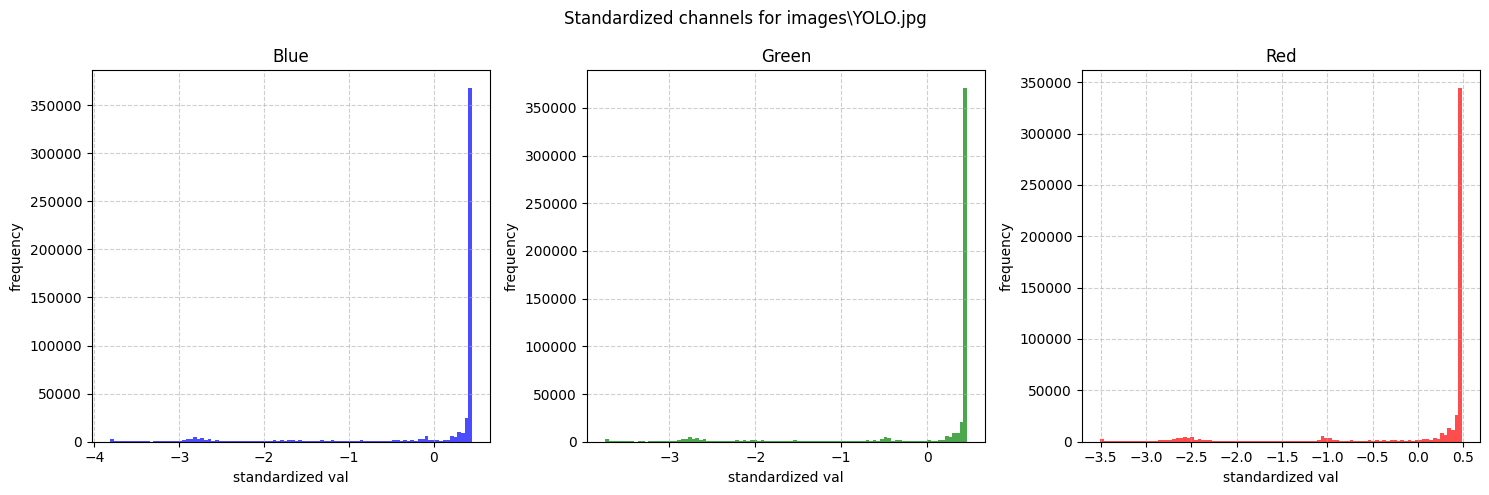

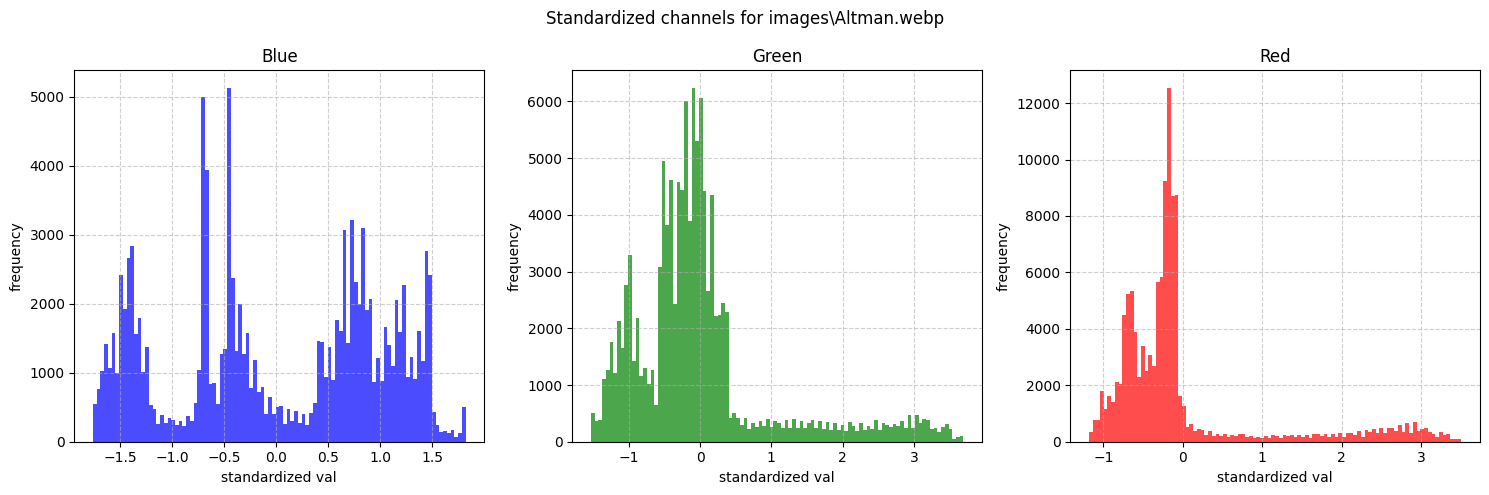

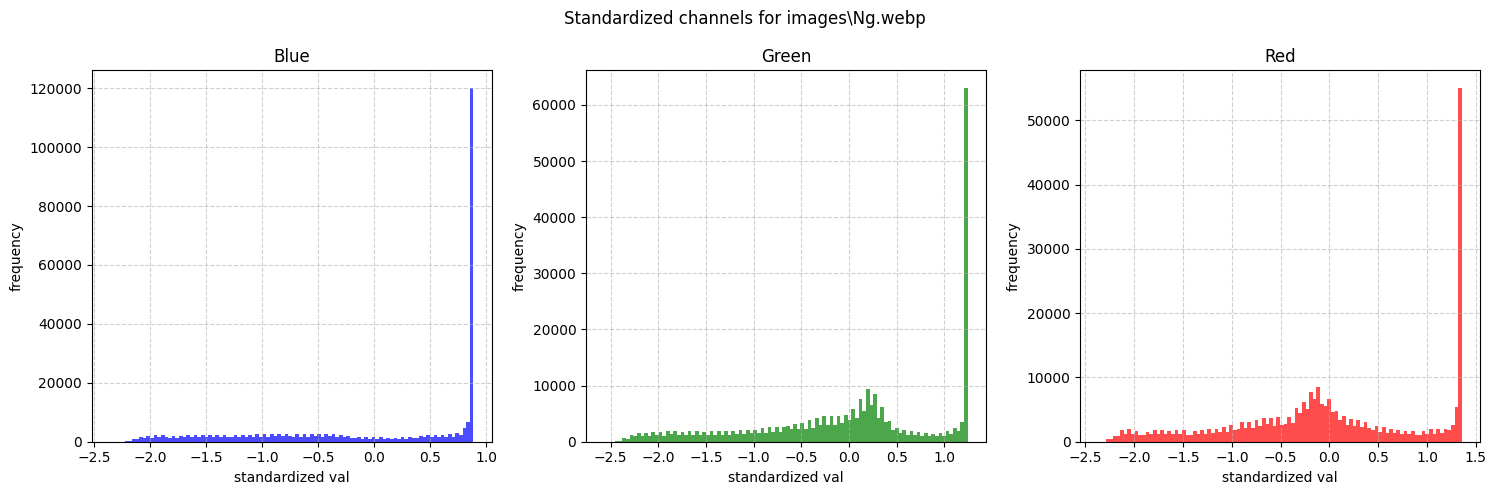

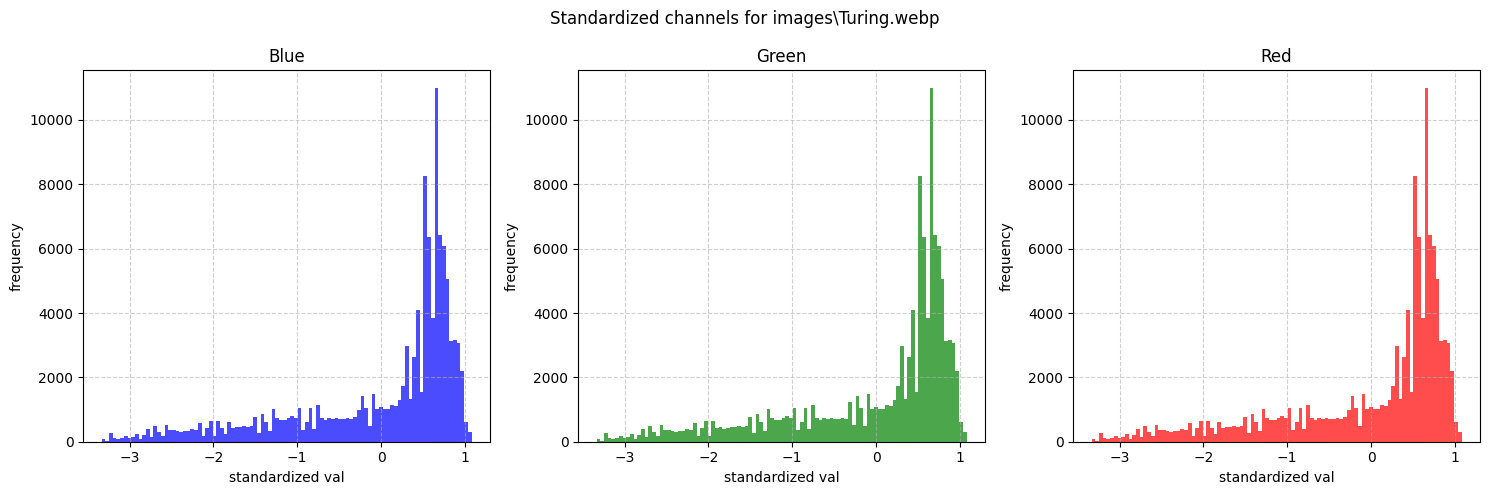

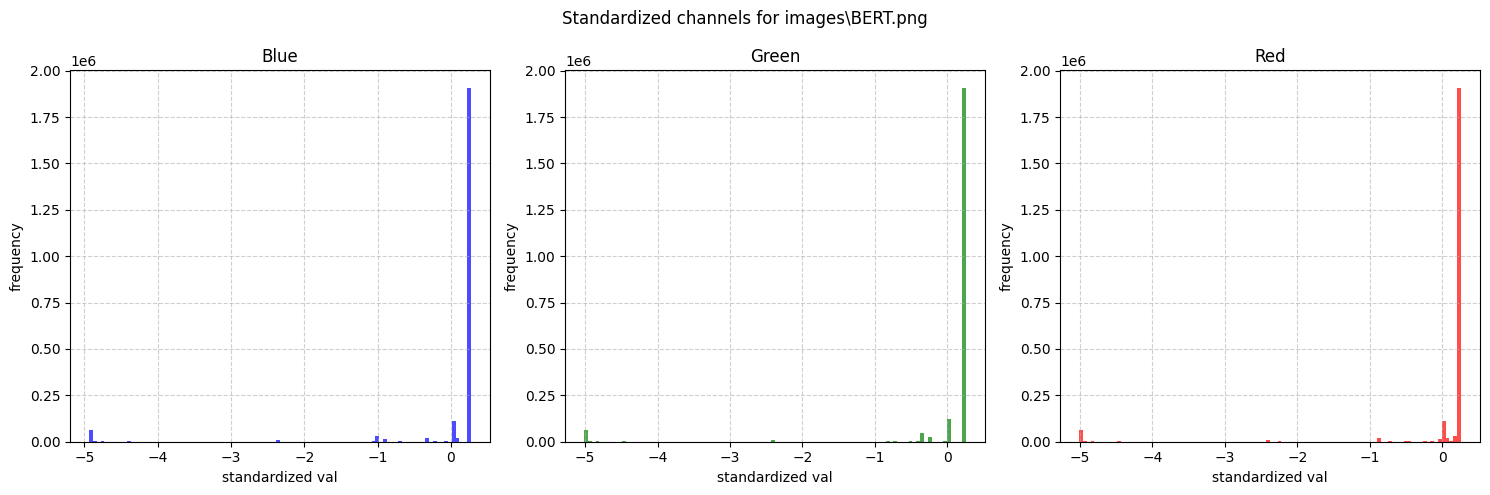

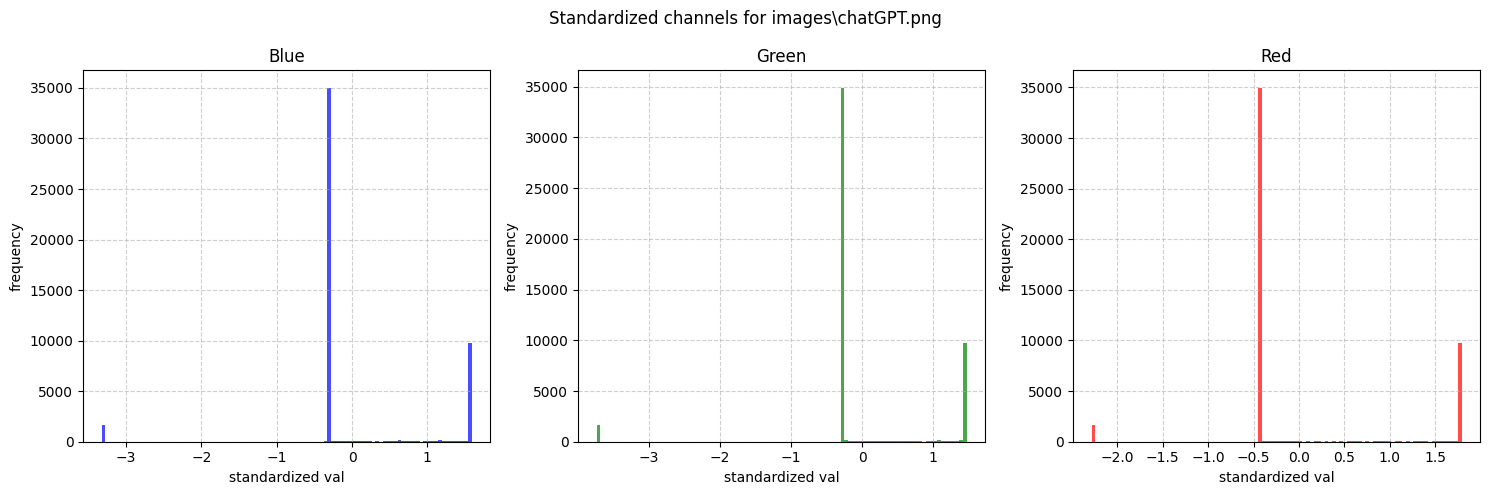

In [17]:
# normalizare exercitiu 2

import cv2

colors=['b','g','r']
channels=['Blue','Green','Red']

for image in images:
    img=cv2.imread(image)
    img=img.astype('float32')
    mean,std=cv2.meanStdDev(img)
    img_standardized=(img-mean.flatten())/std.flatten()
    plt.figure(figsize=(15,5))
    plt.suptitle("Standardized channels for "+ str(image))

    for i in range(3):
        plt.subplot(1,3,i+1)
        channel_data=img_standardized[:,:,i].flatten()

        plt.hist(channel_data,bins=100,color=colors[i],alpha=0.7)
        plt.title(channels[i])
        plt.xlabel("standardized val")
        plt.ylabel("frequency")
        plt.grid(True,linestyle='--',alpha=0.6)
    plt.tight_layout()
    plt.show()

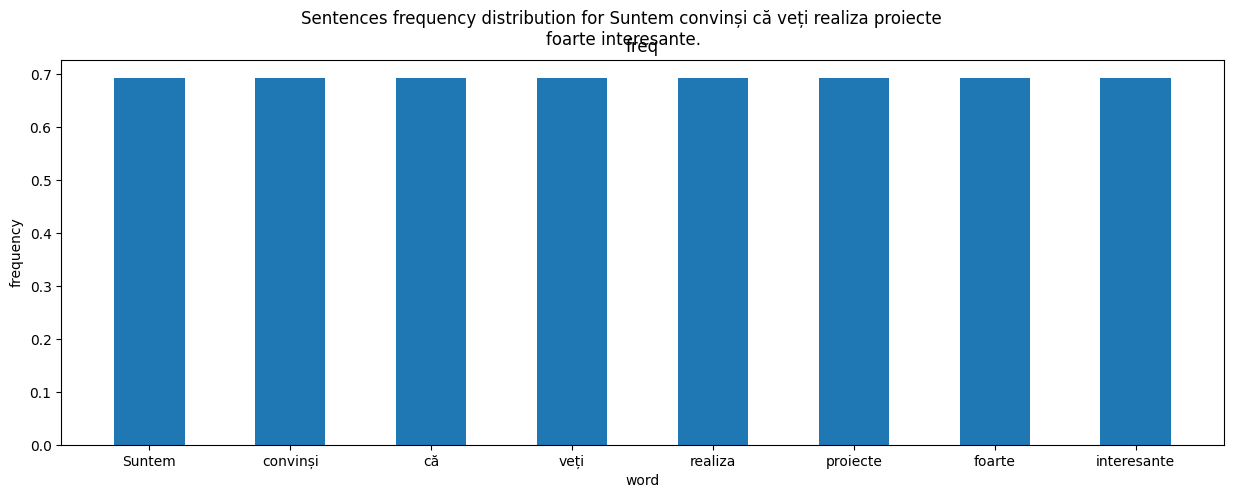

In [18]:
sentence=[sentences[1]]
for sent in sentence:
    freq={}
    tokenized_words = word_tokenize(sent)
    for w in tokenized_words:
        if not w.isalpha() or w.isdigit():
            continue
        freq[w] = freq.get(w, 0) + 1
    freq_scaled=[math.log(x+1) for x in freq.values()]
    plt.figure(figsize=(15,5))
    plt.bar(freq.keys(), freq_scaled, width=0.5)
    plt.suptitle("Sentences frequency distribution for "+ str(sent))
    plt.title("freq")
    plt.xlabel("word")
    plt.ylabel("frequency")
    plt.show()